In [1]:
# ============================================================
# Cell 1 : Imports
# ============================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Cell 2 : Configuration
# ============================================================

SEED = 42

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 0

NUM_CLASSES = 14

EPOCHS = 20

LR = 1e-5

WEIGHT_DECAY = 1e-4

MODEL_PATH = "/kaggle/input/models/swastikprakash/best-supcon-model/pytorch/default/1/best_supcon_encoder.pth"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Device :", DEVICE)

Device : cuda


In [3]:
# ============================================================
# Cell 3 : Check Uploaded Model
# ============================================================

for root, dirs, files in os.walk("/kaggle/input/models"):

    print(root)

    for f in files:

        print("   ", f)

/kaggle/input/models
/kaggle/input/models/swastikprakash
/kaggle/input/models/swastikprakash/supcon
/kaggle/input/models/swastikprakash/supcon/pytorch
/kaggle/input/models/swastikprakash/supcon/pytorch/default
/kaggle/input/models/swastikprakash/supcon/pytorch/default/1
    best_supcon_encoder.pth


In [4]:
# ============================================================
# Cell 4 : Disease Labels
# ============================================================

DISEASES = [

    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"

]

In [5]:
# ============================================================
# Cell 5 : Load Metadata
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

metadata = pd.read_csv(
    os.path.join(
        DATASET_PATH,
        "Data_Entry_2017.csv"
    )
)

metadata = metadata.drop(
    columns=["Unnamed: 11"],
    errors="ignore"
)

print(metadata.shape)

(112120, 11)


In [6]:
# ============================================================
# Cell 6 : Image Paths
# ============================================================

IMAGE_PATH_DICT = {}

image_files = glob(
    os.path.join(
        DATASET_PATH,
        "images_*",
        "images",
        "*.png"
    )
)

for img in image_files:

    IMAGE_PATH_DICT[
        os.path.basename(img)
    ] = img

metadata["Image Path"] = metadata[
    "Image Index"
].map(
    IMAGE_PATH_DICT
)

metadata = metadata.dropna().reset_index(drop=True)

print(metadata.shape)

(112120, 12)


In [7]:
# ============================================================
# Cell 7 : Multi-label Encoding
# ============================================================

for disease in DISEASES:

    metadata[disease] = metadata[
        "Finding Labels"
    ].apply(

        lambda x: int(
            disease in x.split("|")
        )

    )

metadata.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,0,1,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,1,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,0,1,0,0,0,0,0,0


In [8]:
# ============================================================
# Cell 8 : Patient-wise Train / Validation / Test Split
# ============================================================

# -------- First Split (70% Train, 30% Temp) --------

gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(
        metadata,
        groups=metadata["Patient ID"]
    )
)

train_df = metadata.iloc[train_idx].reset_index(drop=True)

temp_df = metadata.iloc[temp_idx].reset_index(drop=True)

# -------- Second Split (20% Val, 10% Test) --------
# temp = 30%
# val = 20/30 = 0.6667 of temp
# test = 10/30 = 0.3333 of temp

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=2/3,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["Patient ID"]
    )
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)

test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("="*60)
print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")
print("="*60)

Train      : 78566
Validation : 22204
Test       : 11350


In [9]:
# ============================================================
# Cell 9 : CLAHE
# ============================================================

def apply_clahe(image):

    clahe = cv2.createCLAHE(

        clipLimit=2,

        tileGridSize=(8,8)

    )

    return clahe.apply(image)

In [10]:
# ============================================================
# Cell 10 : Transform
# ============================================================

transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

In [11]:
# ============================================================
# Cell 11 : Dataset
# ============================================================

class NIHArcFaceDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(

            row["Image Path"],

            cv2.IMREAD_GRAYSCALE

        )

        image = apply_clahe(image)

        image = cv2.cvtColor(

            image,

            cv2.COLOR_GRAY2RGB

        )

        image = transform(image)

        label = row[
            DISEASES
        ].values.astype(np.float32)

        return image, torch.tensor(label)

In [12]:
# ============================================================
# Cell 12 : DataLoaders
# ============================================================

train_dataset = NIHArcFaceDataset(train_df)

val_dataset = NIHArcFaceDataset(val_df)

test_dataset = NIHArcFaceDataset(test_df)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=True

)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=True

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=True

)


print("="*60)
print(f"Train Images      : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")
print(f"Test Images       : {len(test_dataset)}")
print("-"*60)
print(f"Train Batches      : {len(train_loader)}")
print(f"Validation Batches : {len(val_loader)}")
print(f"Test Batches       : {len(test_loader)}")
print("="*60)

Train Images      : 78566
Validation Images : 22204
Test Images       : 11350
------------------------------------------------------------
Train Batches      : 2456
Validation Batches : 694
Test Batches       : 355


In [13]:
# ============================================================
# Cell 13 : Build ConvNeXt Encoder
# ============================================================

weights = ConvNeXt_Tiny_Weights.DEFAULT

backbone = convnext_tiny(weights=weights)

in_features = backbone.classifier[2].in_features

backbone.classifier[2] = nn.Linear(
    in_features,
    NUM_CLASSES
)

backbone = backbone.to(DEVICE)

print(backbone.classifier)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 218MB/s]


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=14, bias=True)
)


In [14]:
# ============================================================
# Cell 14 : Load SupCon Model
# ============================================================

MODEL_PATH = "/kaggle/input/models/swastikprakash/supcon/pytorch/default/1/best_supcon_encoder.pth"

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

print("="*60)
print("Checkpoint Loaded Successfully")
print("="*60)

print(checkpoint.keys())

Checkpoint Loaded Successfully
dict_keys(['encoder_state_dict', 'projection_head_state_dict', 'optimizer_state_dict', 'loss', 'epoch'])


In [15]:
# ============================================================
# Cell 15 : Feature Extractor
# ============================================================

class ConvNeXtFeatureExtractor(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        self.features = backbone.features
        self.avgpool = backbone.avgpool

    def forward(self, x):

        x = self.features(x)

        x = self.avgpool(x)

        x = torch.flatten(x,1)

        return x


encoder = ConvNeXtFeatureExtractor(
    backbone
).to(DEVICE)

In [16]:
# ============================================================
# Cell 16 : Restore SupCon Encoder
# ============================================================

encoder.load_state_dict(
    checkpoint["encoder_state_dict"]
)

encoder.eval()

print("="*60)
print("SupCon Encoder Loaded")
print("="*60)

SupCon Encoder Loaded


In [17]:
# ============================================================
# Cell 17 : Verify Embeddings
# ============================================================

dummy = torch.randn(
    8,
    3,
    224,
    224
).to(DEVICE)

with torch.no_grad():

    emb = encoder(dummy)

print("="*60)

print("Embedding Shape :", emb.shape)

print("="*60)

Embedding Shape : torch.Size([8, 768])


In [18]:
# ============================================================
# Cell 18 : ArcFace Layer
# ============================================================

class ArcMarginProduct(nn.Module):

    def __init__(self,
                 in_features,
                 out_features,
                 s=30.0,
                 m=0.50):

        super().__init__()

        self.s = s
        self.m = m

        self.weight = nn.Parameter(
            torch.FloatTensor(
                out_features,
                in_features
            )
        )

        nn.init.xavier_uniform_(self.weight)

    def forward(self, features):

        features = F.normalize(
            features
        )

        weight = F.normalize(
            self.weight
        )

        cosine = F.linear(
            features,
            weight
        )

        cosine = torch.clamp(
            cosine,
            -1 + 1e-7,
            1 - 1e-7
        )

        theta = torch.acos(cosine)

        logits = torch.cos(
            theta + self.m
        )

        logits *= self.s

        return logits

In [19]:
# ============================================================
# Cell 19 : ArcFace Model
# ============================================================

class ArcFaceModel(nn.Module):

    def __init__(self,
                 encoder):

        super().__init__()

        self.encoder = encoder

        self.arcface = ArcMarginProduct(

            768,

            NUM_CLASSES

        )

    def forward(self,x):

        embedding = self.encoder(x)

        logits = self.arcface(embedding)

        return embedding, logits


arcface_model = ArcFaceModel(
    encoder
).to(DEVICE)

print(arcface_model)

ArcFaceModel(
  (encoder): ConvNeXtFeatureExtractor(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2)

In [20]:
# ============================================================
# Cell 20 : Verify ArcFace
# ============================================================

dummy = torch.randn(
    4,
    3,
    224,
    224
).to(DEVICE)

with torch.no_grad():

    embedding, logits = arcface_model(
        dummy
    )

print("="*60)

print("Embedding :", embedding.shape)

print("Logits :", logits.shape)

print("="*60)

Embedding : torch.Size([4, 768])
Logits : torch.Size([4, 14])


In [21]:
# ============================================================
# Cell 21 : Loss Function
# ============================================================

criterion = nn.BCEWithLogitsLoss()

print("Loss Function : BCEWithLogitsLoss")

Loss Function : BCEWithLogitsLoss


In [22]:
# ============================================================
# Cell 22 : Optimizer
# ============================================================

optimizer = torch.optim.AdamW(

    arcface_model.parameters(),

    lr=1e-5,

    weight_decay=1e-4

)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0.0001
)


In [23]:
# ============================================================
# Cell 23 : Scheduler
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20,

    eta_min=1e-7

)

print("Scheduler Ready")

Scheduler Ready


In [24]:
# ============================================================
# Cell 24 : Mixed Precision
# ============================================================

scaler = torch.cuda.amp.GradScaler()

print("AMP Enabled")

AMP Enabled


In [25]:
# ============================================================
# Cell 25A : Model Information
# ============================================================

total_params = sum(
    p.numel()
    for p in arcface_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in arcface_model.parameters()
    if p.requires_grad
)

print("="*60)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print("="*60)

Total Parameters     : 27,829,344
Trainable Parameters : 27,829,344


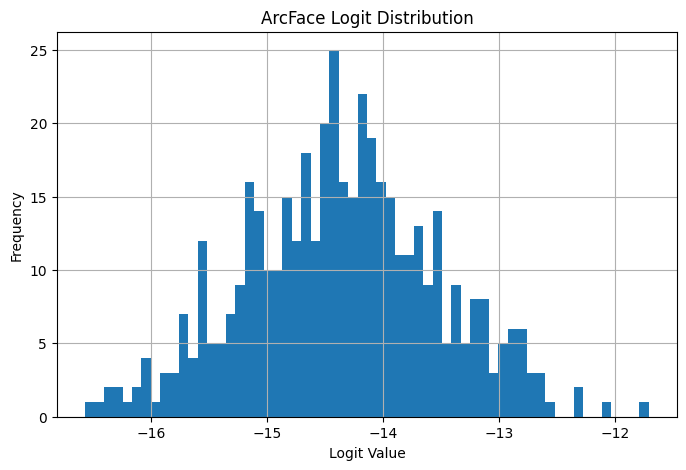

In [26]:
# ============================================================
# Cell 25B : Logit Distribution
# ============================================================

arcface_model.eval()

images, labels = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():

    _, logits = arcface_model(images)

logits = logits.cpu().numpy().flatten()

plt.figure(figsize=(8,5))

plt.hist(
    logits,
    bins=60
)

plt.title("ArcFace Logit Distribution")

plt.xlabel("Logit Value")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

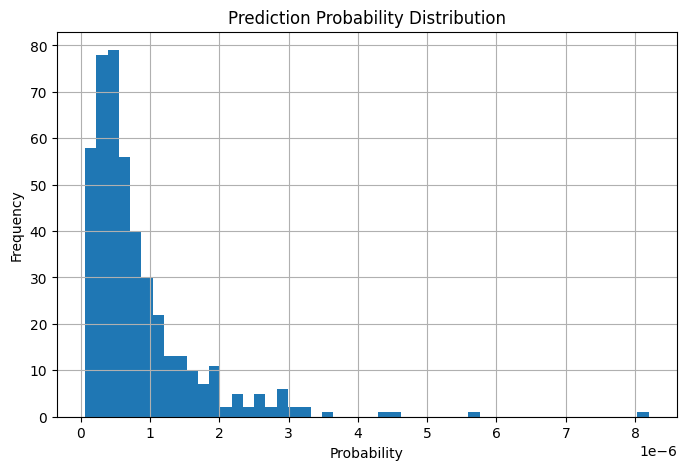

In [27]:
# ============================================================
# Cell 25C : Sigmoid Probability Distribution
# ============================================================

probs = torch.sigmoid(
    torch.tensor(logits)
).numpy()

plt.figure(figsize=(8,5))

plt.hist(
    probs,
    bins=50
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Probability")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [28]:
# ============================================================
# Cell 25D : Embedding Statistics
# ============================================================

arcface_model.eval()

with torch.no_grad():

    embedding, _ = arcface_model(images)

embedding = embedding.cpu().numpy()

print("="*60)

print("Embedding Shape :", embedding.shape)

print("Mean :", embedding.mean())

print("Std :", embedding.std())

print("Min :", embedding.min())

print("Max :", embedding.max())

print("="*60)

Embedding Shape : (32, 768)
Mean : 0.0038933046
Std : 0.1269782
Min : -1.0202081
Max : 1.7087181


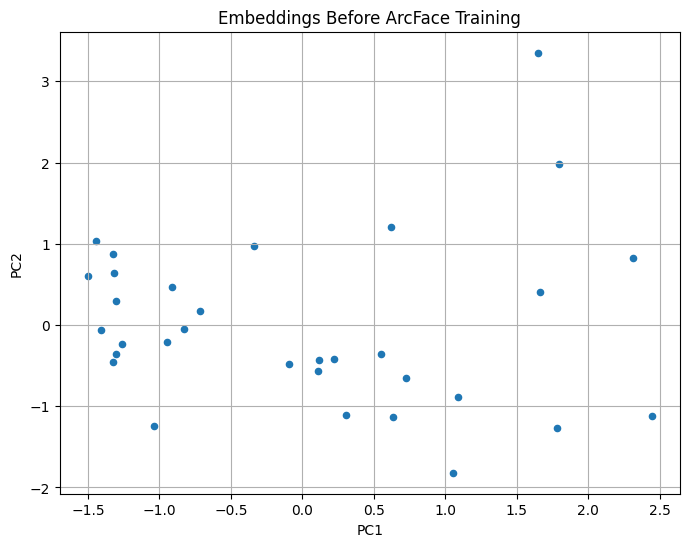

In [29]:
# ============================================================
# Cell 25E : PCA Visualization
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embedding_2d = pca.fit_transform(embedding)

plt.figure(figsize=(8,6))

plt.scatter(

    embedding_2d[:,0],

    embedding_2d[:,1],

    s=20

)

plt.title("Embeddings Before ArcFace Training")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.grid(True)

plt.show()

In [30]:
# ============================================================
# Cell 26 : Optimizer + Scheduler + AMP
# ============================================================

optimizer = torch.optim.AdamW(

    arcface_model.parameters(),

    lr=1e-5,

    weight_decay=1e-4

)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20,

    eta_min=1e-7

)

scaler = torch.cuda.amp.GradScaler()

print("="*60)
print("Optimizer Ready")
print("Scheduler Ready")
print("AMP Enabled")
print("="*60)

Optimizer Ready
Scheduler Ready
AMP Enabled


In [31]:
# ============================================================
# Cell 27 : Train One Epoch
# ============================================================

from sklearn.metrics import roc_auc_score,f1_score,precision_score,recall_score

def train_one_epoch(model,
                    loader,
                    optimizer,
                    criterion):

    model.train()

    running_loss = 0

    all_labels = []

    all_probs = []

    for images, labels in tqdm(loader):

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            _, logits = model(images)

            loss = criterion(logits,labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        probs = torch.sigmoid(logits)

        all_labels.append(labels.detach().cpu())

        all_probs.append(probs.detach().cpu())

    y_true = torch.cat(all_labels).numpy()

    y_prob = torch.cat(all_probs).numpy()

    preds = (y_prob>0.5).astype(int)

    metrics = {

        "loss":running_loss/len(loader),

        "auc":roc_auc_score(
            y_true,
            y_prob,
            average="macro"
        ),

        "f1":f1_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        ),

        "precision":precision_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        ),

        "recall":recall_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        )

    }

    return metrics

In [32]:
# ============================================================
# Cell 28 : Validation
# ============================================================

def validate(model,
             loader,
             criterion):

    model.eval()

    running_loss = 0

    all_labels = []

    all_probs = []

    with torch.no_grad():

        for images,labels in tqdm(loader):

            images = images.to(DEVICE)

            labels = labels.to(DEVICE)

            _,logits = model(images)

            loss = criterion(logits,labels)

            running_loss += loss.item()

            probs = torch.sigmoid(logits)

            all_labels.append(labels.cpu())

            all_probs.append(probs.cpu())

    y_true = torch.cat(all_labels).numpy()

    y_prob = torch.cat(all_probs).numpy()

    preds = (y_prob>0.5).astype(int)

    metrics = {

        "loss":running_loss/len(loader),

        "auc":roc_auc_score(
            y_true,
            y_prob,
            average="macro"
        ),

        "f1":f1_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        ),

        "precision":precision_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        ),

        "recall":recall_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        )

    }

    return metrics

In [33]:
# ============================================================
# Cell 29 : Training Configuration
# ============================================================

EPOCHS = 20

BEST_AUC = 0

PATIENCE = 5

counter = 0

SAVE_PATH = "/kaggle/working/best_arcface_model.pth"

history = {

    "train_loss":[],

    "val_loss":[],

    "train_auc":[],

    "val_auc":[],

    "train_f1":[],

    "val_f1":[],

    "train_precision":[],

    "val_precision":[],

    "train_recall":[],

    "val_recall":[]

}

print("Training Configuration Ready")

Training Configuration Ready


In [34]:
# ============================================================
# Cell 30 : ArcFace Training
# ============================================================

import time

start_time = time.time()

for epoch in range(EPOCHS):

    print("\n" + "="*80)
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print("="*80)

    # --------------------------
    # Train
    # --------------------------

    train_metrics = train_one_epoch(

        arcface_model,

        train_loader,

        optimizer,

        criterion

    )

    # --------------------------
    # Validation
    # --------------------------

    val_metrics = validate(

        arcface_model,

        val_loader,

        criterion

    )

    scheduler.step()

    # --------------------------
    # Save History
    # --------------------------

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])

    history["train_auc"].append(train_metrics["auc"])
    history["val_auc"].append(val_metrics["auc"])

    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])

    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])

    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])

    # --------------------------
    # Print Metrics
    # --------------------------

    print(f"Train Loss      : {train_metrics['loss']:.4f}")
    print(f"Validation Loss : {val_metrics['loss']:.4f}")

    print(f"Train AUROC     : {train_metrics['auc']:.4f}")
    print(f"Validation AUROC: {val_metrics['auc']:.4f}")

    print(f"Train F1        : {train_metrics['f1']:.4f}")
    print(f"Validation F1   : {val_metrics['f1']:.4f}")

    print(f"Train Precision : {train_metrics['precision']:.4f}")
    print(f"Validation Prec.: {val_metrics['precision']:.4f}")

    print(f"Train Recall    : {train_metrics['recall']:.4f}")
    print(f"Validation Rec. : {val_metrics['recall']:.4f}")

    # --------------------------
    # Save Best Model
    # --------------------------

    if val_metrics["auc"] > BEST_AUC:

        BEST_AUC = val_metrics["auc"]

        counter = 0

        torch.save({

            "model_state_dict": arcface_model.state_dict(),

            "optimizer_state_dict": optimizer.state_dict(),

            "scheduler_state_dict": scheduler.state_dict(),

            "history": history,

            "best_auc": BEST_AUC,

            "epoch": epoch

        }, SAVE_PATH)

        print("\n✅ Best ArcFace Model Saved")

    else:

        counter += 1

        print(f"\nNo Improvement ({counter}/{PATIENCE})")

    # --------------------------
    # Early Stopping
    # --------------------------

    if counter >= PATIENCE:

        print("\n🛑 Early Stopping Triggered")

        break


training_time = (time.time() - start_time)/60

print("\n" + "="*80)

print("🎉 ArcFace Training Completed")

print(f"Best Validation AUROC : {BEST_AUC:.4f}")

print(f"Training Time         : {training_time:.2f} minutes")

print(f"Model Saved At        : {SAVE_PATH}")

print("="*80)


Epoch [1/20]


  0%|          | 0/2456 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


  0%|          | 0/694 [00:00<?, ?it/s]

Train Loss      : 0.2080
Validation Loss : 0.1486
Train AUROC     : 0.6596
Validation AUROC: 0.8260
Train F1        : 0.0616
Validation F1   : 0.1471
Train Precision : 0.3520
Validation Prec.: 0.2946
Train Recall    : 0.0352
Validation Rec. : 0.1028

✅ Best ArcFace Model Saved

Epoch [2/20]


...

Train Loss      : 0.0973
Validation Loss : 0.1741
Train AUROC     : 0.9501
Validation AUROC: 0.8166
Train F1        : 0.4496
Validation F1   : 0.2380
Train Precision : 0.7273
Validation Prec.: 0.3731
Train Recall    : 0.3530
Validation Rec. : 0.1897

No Improvement (4/5)

Epoch [7/20]


  0%|          | 0/2456 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


  0%|          | 0/694 [00:00<?, ?it/s]

Train Loss      : 0.0887
Validation Loss : 0.1824
Train AUROC     : 0.9600
Validation AUROC: 0.8113
Train F1        : 0.5034
Validation F1   : 0.2303
Train Precision : 0.7568
Validation Prec.: 0.3585
Train Recall    : 0.4068
Validation Rec. : 0.1808

No Improvement (5/5)

🛑 Early Stopping Triggered

🎉 ArcFace Training Completed
Best Validation AUROC : 0.8371
Training Time         : 422.51 minutes
Model Saved At        : /kaggle/working/best_arcface_model.pth


In [35]:
# ============================================================
# Cell 31 : Load Best ArcFace Model
# ============================================================

checkpoint = torch.load(
    SAVE_PATH,
    map_location=DEVICE,
    weights_only=False
)

arcface_model.load_state_dict(
    checkpoint["model_state_dict"]
)

arcface_model.eval()

print("="*60)
print("Best ArcFace Model Loaded")
print(f"Best AUROC : {checkpoint['best_auc']:.4f}")
print("="*60)

Best ArcFace Model Loaded
Best AUROC : 0.8371


In [36]:
# ============================================================
# Cell 32 : Test Evaluation
# ============================================================

test_metrics = validate(
    arcface_model,
    test_loader,
    criterion
)

print("="*70)
print("TEST RESULTS")
print("="*70)

print(f"Loss      : {test_metrics['loss']:.4f}")
print(f"AUROC     : {test_metrics['auc']:.4f}")
print(f"F1 Score  : {test_metrics['f1']:.4f}")
print(f"Precision : {test_metrics['precision']:.4f}")
print(f"Recall    : {test_metrics['recall']:.4f}")

print("="*70)

  0%|          | 0/355 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


TEST RESULTS
Loss      : 0.1511
AUROC     : 0.8356
F1 Score  : 0.1846
Precision : 0.3613
Recall    : 0.1384


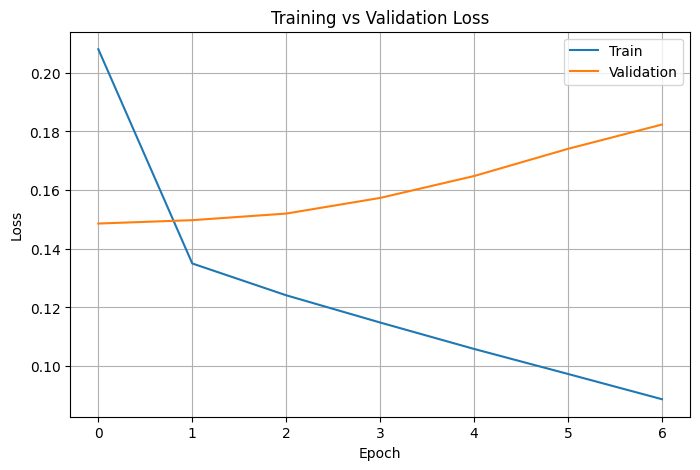

In [37]:
# ============================================================
# Cell 33 : Loss Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history["train_loss"],label="Train")

plt.plot(history["val_loss"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

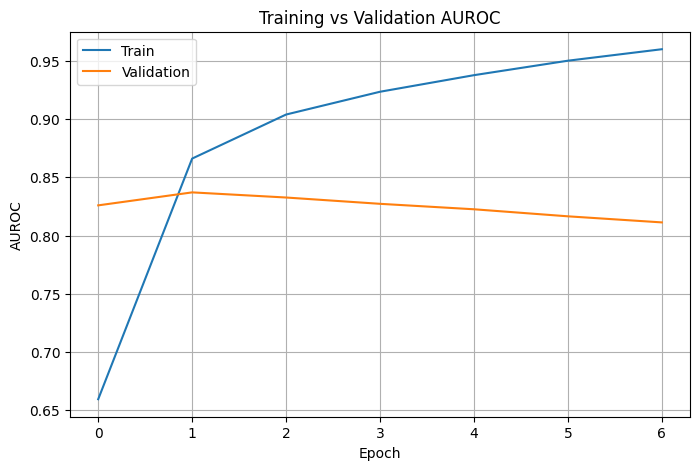

In [38]:
# ============================================================
# Cell 34 : AUROC
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history["train_auc"],label="Train")

plt.plot(history["val_auc"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("AUROC")

plt.title("Training vs Validation AUROC")

plt.legend()

plt.grid(True)

plt.show()

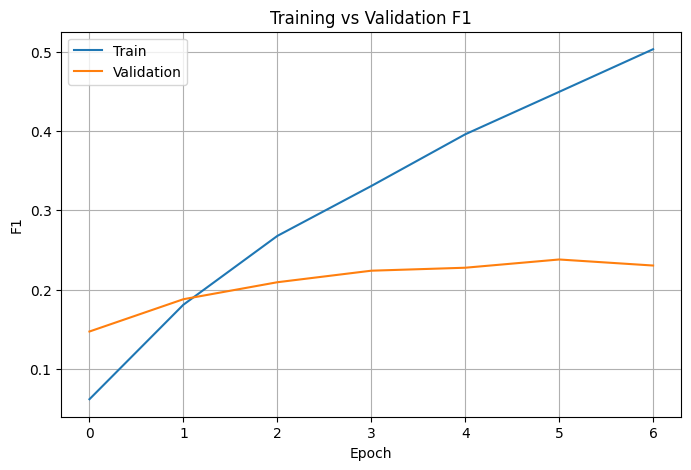

In [39]:
# ============================================================
# Cell 35 : F1 Score
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history["train_f1"],label="Train")

plt.plot(history["val_f1"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("F1")

plt.title("Training vs Validation F1")

plt.legend()

plt.grid(True)

plt.show()

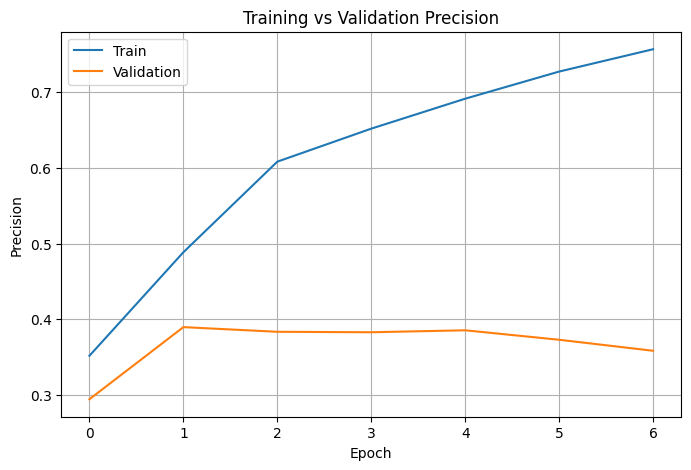

In [40]:
# ============================================================
# Cell 36 : Precision
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history["train_precision"],label="Train")

plt.plot(history["val_precision"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Precision")

plt.title("Training vs Validation Precision")

plt.legend()

plt.grid(True)

plt.show()

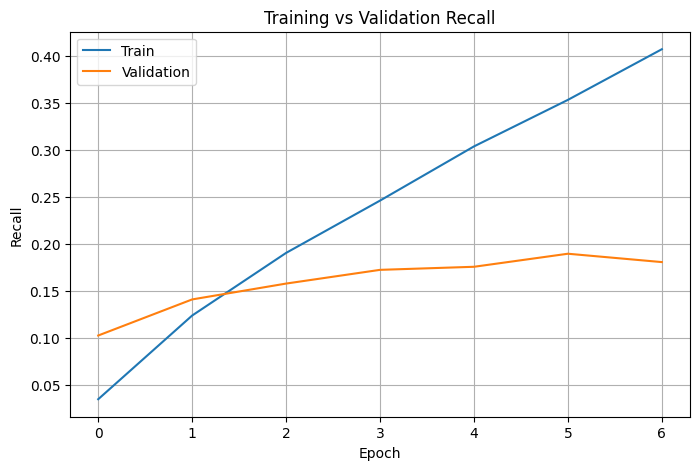

In [41]:
# ============================================================
# Cell 37 : Recall
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history["train_recall"],label="Train")

plt.plot(history["val_recall"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Recall")

plt.title("Training vs Validation Recall")

plt.legend()

plt.grid(True)

plt.show()

In [42]:
# ============================================================
# Cell 38 : Predictions
# ============================================================

arcface_model.eval()

all_labels=[]

all_probs=[]

with torch.no_grad():

    for images,labels in tqdm(test_loader):

        images=images.to(DEVICE)

        labels=labels.to(DEVICE)

        _,logits=arcface_model(images)

        probs=torch.sigmoid(logits)

        all_labels.append(labels.cpu())

        all_probs.append(probs.cpu())

y_true=torch.cat(all_labels).numpy()

y_prob=torch.cat(all_probs).numpy()

y_pred=(y_prob>0.5).astype(int)

print(y_true.shape)

print(y_pred.shape)

  0%|          | 0/355 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


(11350, 14)
(11350, 14)


In [43]:
# ============================================================
# Cell 39 : Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(

classification_report(

y_true,

y_pred,

target_names=DISEASES,

zero_division=0

)

)

                    precision    recall  f1-score   support

       Atelectasis       0.45      0.21      0.29      1165
      Cardiomegaly       0.47      0.27      0.34       329
     Consolidation       0.00      0.00      0.00       460
             Edema       0.32      0.08      0.12       208
          Effusion       0.61      0.36      0.45      1259
         Emphysema       0.49      0.20      0.28       335
          Fibrosis       1.00      0.01      0.01       180
            Hernia       0.00      0.00      0.00        25
      Infiltration       0.43      0.26      0.32      1959
              Mass       0.41      0.25      0.31       514
            Nodule       0.44      0.12      0.19       625
Pleural_Thickening       0.00      0.00      0.00       339
         Pneumonia       0.00      0.00      0.00       133
      Pneumothorax       0.45      0.18      0.26       595

         micro avg       0.47      0.21      0.29      8126
         macro avg       0.36      0.1

In [44]:
# ============================================================
# Cell 40 : Confusion Matrix
# ============================================================

from sklearn.metrics import multilabel_confusion_matrix

cms=multilabel_confusion_matrix(y_true,y_pred)

for i,disease in enumerate(DISEASES):

    print("="*50)

    print(disease)

    print(cms[i])

Atelectasis
[[9880  305]
 [ 918  247]]
Cardiomegaly
[[10920   101]
 [  240    89]]
Consolidation
[[10890     0]
 [  460     0]]
Edema
[[11108    34]
 [  192    16]]
Effusion
[[9802  289]
 [ 806  453]]
Emphysema
[[10947    68]
 [  269    66]]
Fibrosis
[[11170     0]
 [  179     1]]
Hernia
[[11325     0]
 [   25     0]]
Infiltration
[[8698  693]
 [1445  514]]
Mass
[[10653   183]
 [  388   126]]
Nodule
[[10627    98]
 [  548    77]]
Pleural_Thickening
[[11008     3]
 [  339     0]]
Pneumonia
[[11217     0]
 [  133     0]]
Pneumothorax
[[10618   137]
 [  485   110]]


In [45]:
# ============================================================
# Cell 41 : Disease-wise AUROC
# ============================================================

print("="*60)

for i,disease in enumerate(DISEASES):

    auc=roc_auc_score(

        y_true[:,i],

        y_prob[:,i]

    )

    print(f"{disease:20s}: {auc:.4f}")

Atelectasis         : 0.8052
Cardiomegaly        : 0.9086
Consolidation       : 0.7896
Edema               : 0.9031
Effusion            : 0.8713
Emphysema           : 0.9189
Fibrosis            : 0.8074
Hernia              : 0.9029
Infiltration        : 0.7051
Mass                : 0.8443
Nodule              : 0.7670
Pleural_Thickening  : 0.8125
Pneumonia           : 0.7716
Pneumothorax        : 0.8914


In [46]:
# ============================================================
# Cell 42 : Final Save
# ============================================================

torch.save(

arcface_model.state_dict(),

"/kaggle/working/final_arcface_model.pth"

)

print("="*60)

print("Final ArcFace Model Saved")

print("/kaggle/working/final_arcface_model.pth")

print("="*60)

Final ArcFace Model Saved
/kaggle/working/final_arcface_model.pth
